In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Zadanie 1. 
Napisz program, który pozwoli użytkownikowi na wprowadzenie dowolnej ilości wartości temperatury. Kiedy użytkownik wpisze słowo *stop* program przestaje zbierać dane. Wprowadzone wartości mają zostać przepisane na tablicę NumPy wykorzystując typ, który pozwoli najbardziej oszczędzić pamięć operacyjną. Oblicz średnią temperaturę i wyznacz temperatury maksymalną i minimalną. Narysuj wykres boxplot ze wszystkich temperatur i porównaj czy Twoje wyniki zgadzają się z tymi na wykresie. Opisz wnioski.

In [ ]:
temp =  []
while True:
    temp_val = input("Podaj temperaturę w stopniach Celsjusza (lub 'stop' aby zakończyć): ")
    if temp_val == 'stop':
        break
    temp_val_poprawione = temp_val.replace(',', '.')
    try:
        wartosc_liczbowa = float(temp_val_poprawione)
        temp.append(wartosc_liczbowa)
    except ValueError:
        print("Nieprawidłowa wartość. Proszę podać liczbę lub 'stop'.")

print("Wprowadzone temperatury:", temp)

Wprowadzone temperatury: [13.0, 14.5, 23.0, 17.0, 8.0, 9.0, 14.7]


In [ ]:
temp_array = np.array(temp, dtype=np.float16) 
temp_array.dtype


dtype('float16')

In [ ]:
temp_array

array([13. , 14.5, 23. , 17. ,  8. ,  9. , 14.7], dtype=float16)

In [ ]:
srednia = np.mean(temp_array)
print("Średnia temperatura:", srednia)

Średnia temperatura: 14.17


In [ ]:
max = np.max(temp_array)
print("Maksymalna temperatura:", max)

Maksymalna temperatura: 23.0


In [ ]:
min = np.min(temp_array)
print("Minimalna temperatura:", min)

Minimalna temperatura: 8.0


<Axes: >

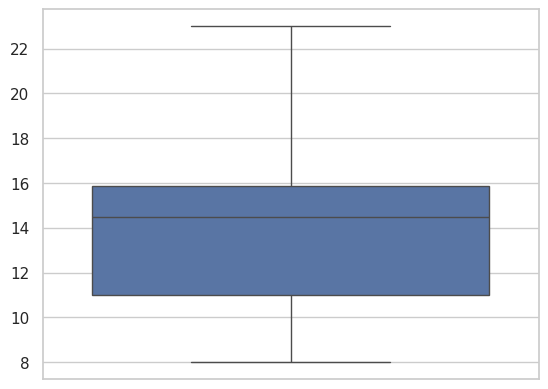

In [ ]:
sns.boxplot(temp_array)


# Zadanie 2.
Zasymuluj schemat mutacji genetycznych w DNA. W tym celu wygeneruj losową sekwencję DNA o długości $5000$ nukleotydów i przypisz do zmiennej `sekw`. Następnie wyznacz 20 wartości z przedziału od $1$ do $5$ w równych odległościach i zapisz w zmiennej `lambdy`. Dla każdej wartości wylosuj 10 liczb z rozkładu Poissona, gdzie wartości z tablicy `lambdy` to $\lambda$ w rozkładzie Poissona, i zapisz tylko medianę z wylosowanego wektora. Wprowadź tyle losowych zmian w wyjściowej sekwencji ile wskazuje losowanie Poissona dla danej wartości $\lambda$. Oblicz odległość między zmutowanymi sekwencjami do oryginalnej. Na wykresie liniowym przedstaw zależność odległości od użytej wartości $\lambda$. Wykorzystaj odległość Hamminga:
$$d_H(x,y)=\sum_{i=1}^n{[x_i\neq y_i]}$$

co oznacza, że każda pozycja, na której obie sekwencje mają różne nukleotydy zwiększa odległość o $1$.

In [ ]:
n  = [ "A", "C", "G", "T" ]
size = 5000
sekw = np.random.choice(n, size=size)
print(sekw)

['A' 'T' 'A' ... 'C' 'C' 'G']


In [ ]:
lambdy= np.linspace(1,5, num = 20)
print(lambdy)

[1.         1.21052632 1.42105263 1.63157895 1.84210526 2.05263158
 2.26315789 2.47368421 2.68421053 2.89473684 3.10526316 3.31578947
 3.52631579 3.73684211 3.94736842 4.15789474 4.36842105 4.57894737
 4.78947368 5.        ]


In [ ]:
los = []
for l in lambdy:
   wylosowany_wektor = np.random.poisson(lam=l, size=10)
   mediana = np.median(wylosowany_wektor)
   los.append(mediana)
print(los)

[np.float64(0.5), np.float64(1.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.5), np.float64(2.5), np.float64(1.5), np.float64(2.0), np.float64(3.0), np.float64(3.0), np.float64(2.5), np.float64(5.0), np.float64(4.0), np.float64(4.0), np.float64(3.0), np.float64(2.5), np.float64(5.0), np.float64(6.5), np.float64(3.5)]


In [ ]:
odleglosc = []
for mediana in los:
    lm = int(mediana)
    zmutowana_sekw = sekw.copy()
    pozycje = np.random.choice(5000, size=lm, replace=False)
    podmiana = np.random.choice(n, size=lm)
    zmutowana_sekw[pozycje] = podmiana
    odleglosc_h = np.sum(sekw != zmutowana_sekw)
    odleglosc.append(odleglosc_h)
print(odleglosc)


[np.int64(0), np.int64(1), np.int64(0), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(3), np.int64(3), np.int64(2), np.int64(4), np.int64(3), np.int64(3), np.int64(1), np.int64(2), np.int64(5), np.int64(4), np.int64(3)]


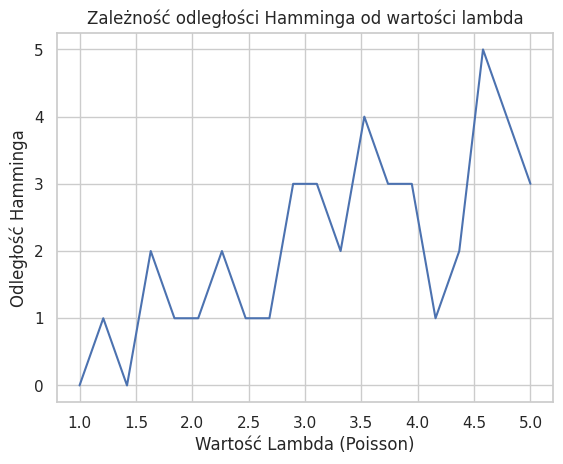

In [ ]:
sns.lineplot(x=lambdy, y=odleglosc)
plt.title("Zależność odległości Hamminga od wartości lambda")
plt.xlabel("Wartość Lambda (Poisson)")
plt.ylabel("Odległość Hamminga")
plt.show()

# Zadanie 3.

Rozwiąż poniższy układ równań wykorzystując algorytm macierzowy eliminacji Gaussa. Algorytm ten opiera się na trzech krokach:
1. Zapisz układ równań w postaci macierzowej - wybieramy współczynniki równań i wstawiamy je do macierzy, np. $2x+5y+3z=7$ ma współczynniki $[2,5,3,7]$ i wektor ten stanowi wektor macierzy.
2. Wykonuj operacje elementarne na wierszach aż do uzyskania macierzy schodkowej - operacje elementarne macierzy to:
    * zamiana dwóch wierszy miejscami;
    * mnożenie wiersza przez niezerową liczbę;
    * dodanie wielokrotności jednego wiersza do innego.

Postać schodkowa macierzy to forma, w której niezerowe wiersze tworzą schody: każdy kolejny wiersz zaczyna się dalej w prawo niż poprzedni, a wszystkie wiersze złożone wyłącznie z zer znajdują się na dole.
3. Wykonuj podstawianie wsteczne - ostatni niezerowy wiersz macierzy ma tylko dwie niezerowe wartości. Pierwsza to współczynnik ostatniej zmiennej, a druga to wartość, której będzie równa zmienna po przemnożeniu przez współczynnik. Przykładowo, ostatni wektor macierzy to 
$$\left[0,0,0,3,15\right]$$
w takim układzie podstawiamy: 
$$0x+0y+0z+3t=15$$
$$3t=15\quad|:3$$
$$t=5$$

W ten sposób podstawiając znane wartości można odnaleźć wartości pozostałych równań.

Układ równań do rozwiązania:
$$t+13u-5v-0.5w=10$$
$$-t+2u-v+x=4$$
$$10u+2v+5w-x=12$$
$$-3t+u-2v+5w=7$$
$$8t+6u-x=3$$

In [ ]:
W = np.array([
    [ 1,  13, -5, -0.5,  0],
    [-1,   2, -1,    0,  1],
    [ 0,  10,  2,    5, -1],
    [-3,   1, -2,    5,  0],
    [ 8,   6,  0,    0, -1]
], dtype=float)

In [ ]:
B = np.array([10, 4, 12, 7, 3], dtype=float)

In [ ]:
wynik = np.linalg.solve(W, B)

In [ ]:
print("Rozwiązanie [t, u, v, w, x]:")
print(np.round(wynik, 3))

Rozwiązanie [t, u, v, w, x]:
[ 0.075  0.808 -0.012  1.278  2.447]


# Zadanie 4.
Tablica `ref` zawiera sekwencję referencyjną (punkt odniesienia), a tablica `sekw` zawiera sekwencje do sprawdzenia. Wykorzystując algorytm map-reduce, oceń jakość sekwencji w stosunku do referencji.

**Mapowanie:** oblicz odległość Hamminga wszystkich sekwencji w stosunku do referencji.

**Redukcja:** oblicz średnią odległość ze wszystkich sekwencji.

In [ ]:
ref = np.array(['A','C','T','G'],dtype='S1')[np.random.randint(0,4,1000)]
sekw = np.array(['A','C','T','G'],dtype='S1')[np.random.randint(0,4,(100,1000))]

In [ ]:
roznice = (ref != sekw)
odleglosc_h = np.sum(roznice, axis=1)
srednia_odleglosc = np.mean(odleglosc_h)
print("Średnia odległość Hamminga:", srednia_odleglosc)


Średnia odległość Hamminga: 749.4
